# Reconocimiento de Actividad Humana con Machine Learning
### Proyecto Final — Machine Learning

---

| | |
|---|---|
| **Equipo** | Grupo 04 |
| **Integrantes** | Jorge Rojas · Juan Madariaga |
| **Fecha** | 29-06-2026 |
| **Dataset** | UCI HAR — Human Activity Recognition Using Smartphones |

---

> **Objetivo de la Fase 3:** Comunicar los resultados del proyecto de forma clara y coherente, integrando el trabajo de las tres fases con una narrativa que explique decisiones, limitaciones y aprendizajes.

## Configuración del entorno

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, urllib.request, zipfile, time, warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Entorno listo.')

/home/ledavinshi/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Entorno listo.


In [3]:
# Carga de datos (mismo código que Fase 1)
import os, urllib.request, zipfile

DATA_PATH = 'UCI HAR Dataset'

if not os.path.exists(DATA_PATH):
    URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
    urllib.request.urlretrieve(URL, 'har_dataset.zip')
    with zipfile.ZipFile('har_dataset.zip', 'r') as z:
        z.extractall('.')
    os.remove('har_dataset.zip')

features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

counts = {}
unique_feature_names = []
for n in feature_names:
    if n in counts:
        counts[n] += 1
        unique_feature_names.append(f"{n}_{counts[n]}")
    else:
        counts[n] = 0
        unique_feature_names.append(n)

feature_names = unique_feature_names
X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=feature_names)

# TODO: Cargar y_train (sin header)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['label'])

# TODO: Cargar X_test y asignar feature_names como columnas
X_test = pd.read_csv(f'{DATA_PATH}/test/X_test.txt', sep=r'\s+', header=None, names=feature_names)

# TODO: Cargar y_test (sin header)
y_test = pd.read_csv(f'{DATA_PATH}/test/y_test.txt', sep=r'\s+', header=None, names=['label'])

ACTIVITY_LABELS = {1:'WALKING',2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',4:'SITTING',5:'STANDING',6:'LAYING'}
y_train_labels = y_train['label'].map(ACTIVITY_LABELS)
y_test_labels  = y_test['label'].map(ACTIVITY_LABELS)

print('Datos cargados:')
print(f'  X_train: {X_train.shape} | X_test: {X_test.shape}')

Datos cargados:
  X_train: (7352, 561) | X_test: (2947, 561)


---
## 1. Introducción

### ¿Por qué es relevante el reconocimiento de actividad humana (HAR)?

El reconocimiento automático de actividades físicas a partir de sensores inerciales tiene aplicaciones directas en salud digital, rehabilitación, deporte y dispositivos móviles. Poder determinar si una persona está caminando, sentada o acostada —sin intervención manual— permite construir sistemas de monitoreo continuo que son tanto no invasivos como de bajo costo.

En este proyecto trabajamos con el dataset **UCI HAR**, que contiene mediciones de acelerómetro y giroscopio de 30 voluntarios (edades 19–48) realizando 6 actividades cotidianas con un smartphone en la cintura. A partir de las señales se extrajeron **561 features** en dominios de tiempo y frecuencia, lo que hace de este problema un caso real de clasificación multiclase en alta dimensionalidad.

In [4]:
# Descripción del dataset
print('Dataset UCI HAR')
print(f'  Sujetos:           30 voluntarios')
print(f'  Actividades:       {len(ACTIVITY_LABELS)} clases')
print(f'  Features:          {X_train.shape[1]}')
print(f'  Muestras train:    {X_train.shape[0]}')
print(f'  Muestras test:     {X_test.shape[0]}')
print(f'  Clases:            {list(ACTIVITY_LABELS.values())}')

Dataset UCI HAR
  Sujetos:           30 voluntarios
  Actividades:       6 clases
  Features:          561
  Muestras train:    7352
  Muestras test:     2947
  Clases:            ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


---
## 2. Resumen Fase 1: Hallazgos del EDA

*[Redactar aquí un párrafo narrativo con los principales hallazgos del análisis exploratorio: balance de clases, features más discriminativas, observaciones del PCA, etc. No copiar todas las visualizaciones — elegir las más relevantes.]*

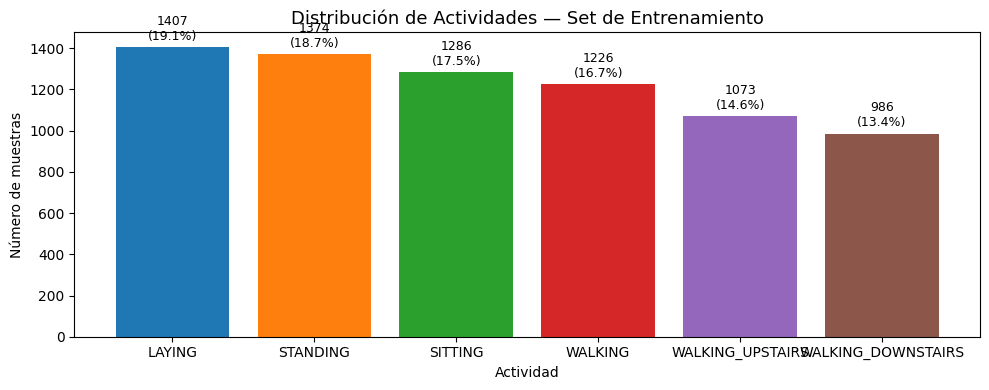

In [5]:
# --- Visualización 1 (de Fase 1): Distribución de clases ---
class_counts = y_train_labels.value_counts()
total = len(y_train_labels)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette('tab10', n_colors=6))
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count}\n({count/total:.1%})', ha='center', va='bottom', fontsize=9)
ax.set_title('Distribución de Actividades — Set de Entrenamiento', fontsize=13)
ax.set_xlabel('Actividad')
ax.set_ylabel('Número de muestras')
plt.tight_layout()
plt.show()

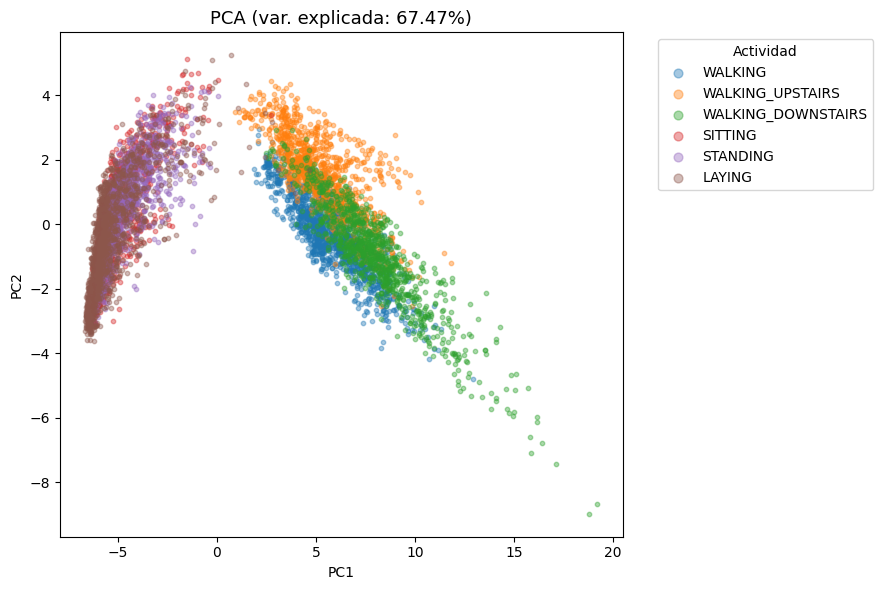

In [6]:
# --- Visualización 2 (de Fase 1): PCA ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train)
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['Activity'] = y_train_labels.values

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('tab10', n_colors=6)
for i, act in enumerate(ACTIVITY_LABELS.values()):
    mask = df_pca['Activity'] == act
    ax.scatter(df_pca.loc[mask,'PC1'], df_pca.loc[mask,'PC2'],
               label=act, alpha=0.4, s=10, color=palette[i])
ax.set_title(f'PCA (var. explicada: {sum(pca.explained_variance_ratio_):.2%})', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Actividad', bbox_to_anchor=(1.05,1), loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

**Principales hallazgos del EDA:**

*[Describe los hallazgos más importantes: ¿el dataset estaba balanceado? ¿Qué features separaban mejor las clases? ¿Qué muestra el PCA sobre la separabilidad? Mínimo 3 observaciones con justificación.]*

El dataset no está balanceado completamente, hay una diferencia notable entre la actividad con menos datos y la con mayor datos, teniendo una variación incremental entre cada una de las actividades.

Las features que mejor separan las clases vistas previamente son aquellas que están relacionadas con el movimiento, debido a que nos permite diferenciar entre las actividades estáticas y aquellas en movimiento.

Podemos observar en el grafico PCA que la actividades estáticas están acopladas a la izquierda y que las actividades en movimiento están a la derecha, es decir, las actividades en movimiento son facilmente diferenciables de las actividades estáticas.

---
## 3. Resumen Fase 2: Benchmarking de Modelos

Entrenamos 6 modelos (incluyendo baseline trivial) con parámetros por defecto de sklearn y los comparamos en el set de prueba usando F1-macro como métrica principal.

In [7]:
# Re-entrenar todos los modelos para el notebook integrado
import time

def entrenar(nombre, modelo):
    t0 = time.time()
    modelo.fit(X_train, y_train)
    t = time.time() - t0
    y_pred = modelo.predict(X_test)
    return {
        'Modelo': nombre,
        'Accuracy_Test': accuracy_score(y_test, y_pred),
        'F1_Macro':   f1_score(y_test, y_pred, average='macro'),
        'F1_Weighted':f1_score(y_test, y_pred, average='weighted'),
        'Tiempo_Entrenamiento': round(t, 3),
        'modelo_obj': modelo,
        'y_pred': y_pred
    }

modelos = [
    ('DummyClassifier',    DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)),
    ('Logistic Regression',LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ('KNN (k=5)',          KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree',      DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('Random Forest',      RandomForestClassifier(random_state=RANDOM_STATE)),
    ('SVM (RBF)',          SVC(kernel='rbf', random_state=RANDOM_STATE)),
]

resultados = [entrenar(n, m) for n, m in modelos]
print('Entrenamiento completado.')

Entrenamiento completado.


In [8]:
# Tabla de benchmarking
df_bench = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('modelo_obj','y_pred')}
    for r in resultados
]).sort_values('F1_Macro', ascending=False).reset_index(drop=True)

print(df_bench.to_string(index=False))

             Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
Logistic Regression       0.960299  0.960152     0.960152                10.308
          SVM (RBF)       0.950458  0.949907     0.950376                 1.544
      Random Forest       0.925687  0.924103     0.925544                10.041
          KNN (k=5)       0.901595  0.898521     0.900698                 0.036
      Decision Tree       0.862233  0.859469     0.861652                 4.226
    DummyClassifier       0.182219  0.051378     0.056172                 0.002


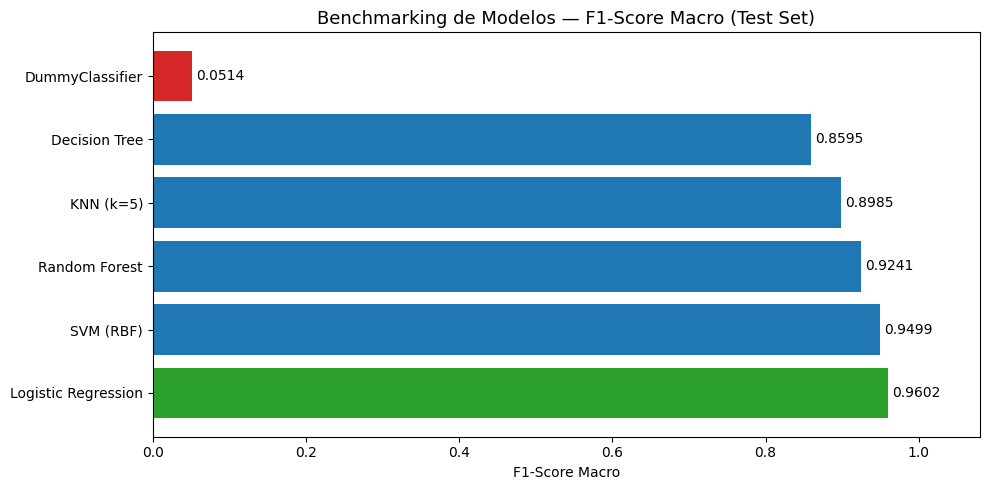

In [9]:
# Barplot comparativo
fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#d62728' if r['Modelo']=='DummyClassifier' else '#1f77b4' for r in resultados]
df_plot = df_bench.copy()
bars = ax.barh(df_plot['Modelo'], df_plot['F1_Macro'],
               color=['#2ca02c' if i==0 else '#1f77b4' if j!='DummyClassifier' else '#d62728'
                      for i,(j) in enumerate(df_plot['Modelo'])])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlim(0, 1.08)
ax.set_xlabel('F1-Score Macro')
ax.set_title('Benchmarking de Modelos — F1-Score Macro (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

**Modelo seleccionado:** *Logistic Regression*

**Justificación:** *[¿Por qué este modelo? Considera F1-macro, tiempo de entrenamiento y cualquier otro factor relevante. ¿Existe un trade-off entre rendimiento y costo computacional que el equipo deba mencionar?]*

El modelo Logistic Regression es el ganador por tener un F1-Macro mayor, el F1 Score representa un intermedio aceptable entre el Accuracy y el Recall, aunque esta es la forma general de determinar el mejor modelo es aceptable igualmente un F1 Score menor pero con un menor tiempo de entrenamiento, este es el trade-off que tenemos en este caso, mientras que Logistic Regression tiene un tiempo de entrenamiento de 10 segundos, SVM posee un tiempo de entrenamiento de 2 segundos con un F1 algo menor que puede ser despreciable.

---
## 4. Análisis de Errores

¿Dónde falla el modelo seleccionado? Esta sección explica qué actividades se confunden y por qué.

Modelo seleccionado para la matriz de confusión: Logistic Regression
F1-Macro del modelo seleccionado: 0.9602


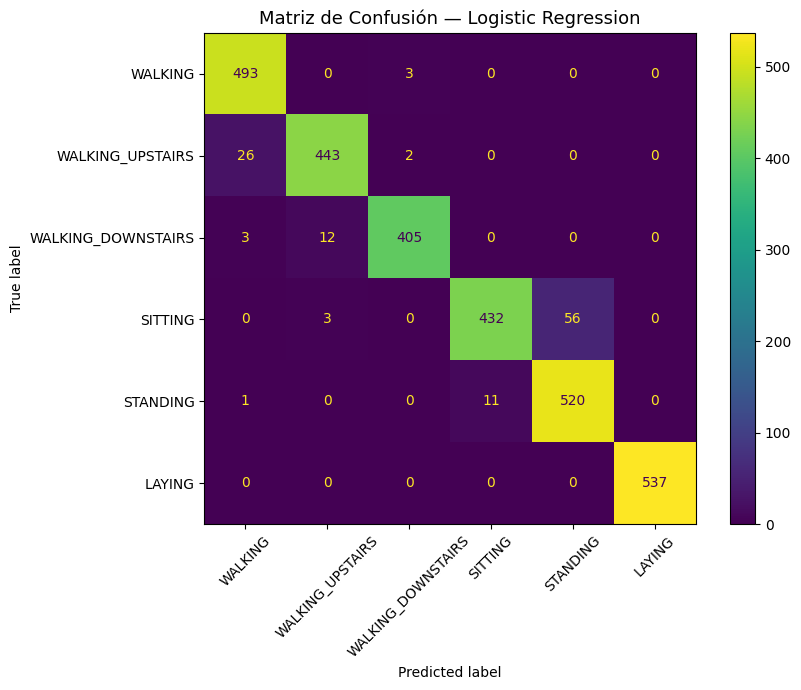

In [10]:
# Matriz de confusión del mejor modelo
# Buscar el mejor modelo por nombre en la lista de resultados
nombre_mejor = df_bench.iloc[0]['Modelo']
mejor = next(r for r in resultados if r['Modelo'] == nombre_mejor)
y_pred_best = mejor['y_pred']

print(f"Modelo seleccionado para la matriz de confusión: {mejor['Modelo']}")
print(f"F1-Macro del modelo seleccionado: {mejor['F1_Macro']:.4f}")

# Convertir predicciones numéricas a etiquetas de actividad
y_pred_labels = pd.Series(y_pred_best).map(ACTIVITY_LABELS)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix(
        y_test_labels, y_pred_labels,
        labels=list(ACTIVITY_LABELS.values())
    ),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title(f'Matriz de Confusión — {mejor["Modelo"]}', fontsize=13)
plt.tight_layout()
plt.show()

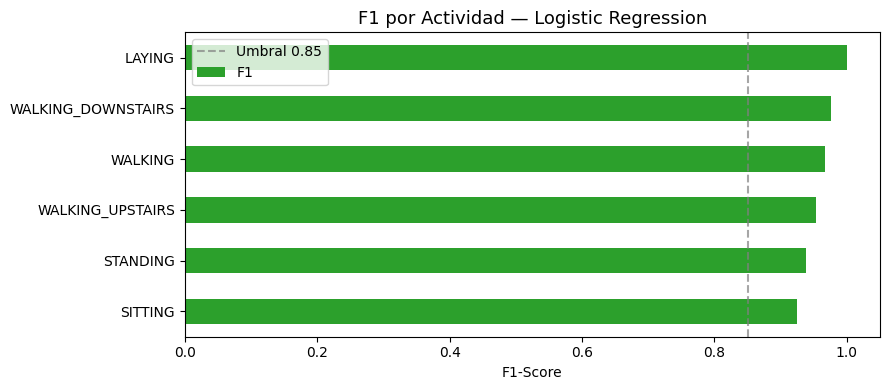

In [11]:
# F1 por clase del mejor modelo
report = classification_report(
    y_test_labels,
    pd.Series(mejor['y_pred']).map(ACTIVITY_LABELS),
    output_dict=True
)
f1_por_clase = {cls: report[cls]['f1-score'] for cls in ACTIVITY_LABELS.values() if cls in report}
df_f1 = pd.Series(f1_por_clase, name='F1').sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if v < 0.85 else '#2ca02c' for v in df_f1.values]
df_f1.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.85, linestyle='--', color='gray', alpha=0.7, label='Umbral 0.85')
ax.set_xlabel('F1-Score')
ax.set_title(f'F1 por Actividad — {mejor["Modelo"]}', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Actividades difíciles:**

*[¿Qué actividades tienen el F1 más bajo? ¿Con cuáles otras se confunden (observar la matriz de confusión)? ¿Tiene sentido físico esta confusión? Por ejemplo: SITTING y STANDING producen señales de acelerómetro similares porque ambas son actividades estáticas.]*

Las actividades con el F1 más bajo son standing y sitting, que son faciles de confundir entre sí por tene r poco movimiento, el acelerometro se encuentra en alturas similares y a velocidades cercanas a 0, por lo que es dificil determinarlas y para explicar que Laying tenga un Score tan alto se explica facilmente indicando que utiliza el medidor de aceleración de gravedad, que tiene valores distintos cuando se apoya a nivel de suelo.

---
## 5. Limitaciones del Modelo

*[Responder con desarrollo propio. Guías de reflexión:]*

**Generalización a nuevos sujetos:** El modelo fue entrenado con 21 sujetos y evaluado en 9. ¿Qué pasaría con sujetos muy diferentes (adultos mayores, personas con movilidad reducida)?

- R: El añadir otros sujetos empeoraría los errores en las matrices de confusión, pues la motricidad de los individuos borde (como personas con movilidad reducida o adultos mayores) es muy diferente a los sujetos que están presentes en este dataset, pues son datos recopilados de personas jovenes.

**Sesgo del dispositivo:** Los datos provienen de un único modelo de smartphone (Samsung Galaxy S II, 50 Hz). ¿Funcionaría igual en un reloj inteligente o un iPhone?

- R: Los datos dependen de la posición y el movimiento del dispositivo, por lo que no funcionarían de igual forma, pues un telefono se encuentra a altura de la cadera puesto en un bolsillo, mientras que un reloj se mueve más y puede tener inperfecciones, por otra parte es posible que un telefono iPhone funcione, pero depende mucho de el como toma las medidas y si los datos obtenidos son muy diferentes.

**Features precomputadas:** Trabajamos con 561 features ya extraídas, no con señales crudas. El pipeline de extracción de features es una caja negra para nosotros.

- R: El hecho de que las 561 caracteristicas ya estén extraidas del conjunto de datos nos impide conocer qué información se perdió o transformó durante el proceso de su extracción, además no nos es posible evaluar si existen otras características que sean relevantes que podrían mejorar el rendimiento del modelo.

**Actividades limitadas:** Solo se modelan 6 actividades. El mundo real tiene decenas de actividades y transiciones entre ellas.

- R: El conjunto de datos se limita a estas 6 actividades, aún así podría haberse planteado de forma más amplia el conjunto de datos para aglomerar más actividades como saltar, correr, trotar, etc. Por ello el desempeño de estos modelos asume que las personas solo realizan estas actividades y puede asumir que, por ejemplo, una persona está caminando cuando en verdad está caminando.

**Mejoras posibles:** ¿Qué agregarían? (Optimización de hiperparámetros, deep learning sobre señales crudas, más actividades, validación por sujeto, etc.)

- R: Una mejora simple que hubiese hecho es que la extracción de datos posea más actividades y sujetos de distintos rangos de edad, realizando una medición manual por sujeto, donde cada uno debe realizar actividades de forma normal y, antes o durante su realización, determinan que actividad específica está siendo realizada, de esta forma poseemos un conjunto de datos que sea más amplio y permita acomodarse a situaciones reales.

- Por el lado más tecnico podríamos realizar una optimización de hiperparámetros, buscando una configuración de maximo rendimiento. Tambíen utilizar tecnicas de deep learning sobre los datos crudos de acelerometro y giroscopio, permitiendo al modelo aprender caracteristicas especificas relevantes de estos.

---
## 6. Conclusión

El modelo que mejor clasificó las actividades fue Logistic Regression, posiblemente debido a que trabajamos con características que permiten a un modelo lineal capturar la información relevante sin necesitar estructuras complejtas, además de que es un modelo simple que presenta riesgo bajo de sobreajuste.

Tres aprendizajes de este proyecto:

1) Podemos realizar pruebas bastante interesantes con conjuntos de datos, nos podrían permitir predecir o clasificar en base a heuristicas cualquier cosa medible, además de que el proceso de análisis de datos es bastante simple y nos permite ver problemas o características del conjunto de datos antes de si quiera entrenar un modelo específico.
2) Es muy facil que un dataset esté mal enfocado, es decir, que los datos medidos estén sesgados por el sujeto, dispositivo, características del ambiente u otras variables que pueden impedir el uso de estos para entrenar un modelo para una tarea específica (con sesgo en este caso nos referimos a un elemento crucial que evita que el modelo pueda aplicarse a cualquier circunstancia), Por ejemplo este dataset no sirve para clasificar los movimientos de una persona mayor de edad pues su movimiento no es igual que los sujetos del dataset.
3) Es importante diferenciar los datos en secciones para que no se mezclen y exista sobreajuste o memorización, un conjunto de entrenamiento muy grande puede provocar que el modelo se confíe y generalice en las respuetas o si el conjunto de datos de entrenamiento posee muchos datos repetidos el modelo solo memorizará las respuestas y no funcionará para datos nuevos.

En caso de tener más tiempo realizaría una aplicación que permita a las empresas saber en qué momento es mejor poner anuncios para una persona, si está en movimiento puede estar menos dispuesta a recibir anuncios, pero si está acostada o sentada por un tiempo determinado asumimos que está descansando y podemos poner anuncios y que exista una mayor disponibilidad a verlo.

Este tipo de modelo puede llegar a utilizarse por el area de la salud para determinar si un paciente se encuentra en buen estado, por ejemplo si un adulto mayor pasa de estar bajando o subiendo escaleras a estar acostado esto puede servir como alerta para saber si tuvo algún accidente.

Por otro lado en el ambito del deporte nos sirve para medir los tiempos de descanso comparados con los de movimiento, midiendo el tiempo de movimiento vs el tiempo estático y brindando información util para los usuarios.

Finalmente podemos decir que machine learning es una rama de las ciencias de la computación que puede extrapolarse a muchos hambitos del día a día que sean medibles, pudiendo resolver problemas en base de un conjunto de datos lo suficientemente vasto. Sin embargo, la calidad de los resultados depende en gran medida de la calidad de los datos, del diseño experimental y de una correcta selección y evaluación de los modelos utilizados.

In [12]:
print('=' * 55)
print('RESUMEN FINAL DEL PROYECTO')
print('=' * 55)
print(f'Dataset:           UCI HAR (10,299 muestras, 561 features)')
print(f'Modelos evaluados: {len(df_bench)}')
print(f'Mejor modelo:      {df_bench.iloc[0]["Modelo"]}')
print(f'F1-Macro (test):   {df_bench.iloc[0]["F1_Macro"]:.4f}')
print(f'Accuracy (test):   {df_bench.iloc[0]["Accuracy_Test"]:.4f}')
print('=' * 55)

RESUMEN FINAL DEL PROYECTO
Dataset:           UCI HAR (10,299 muestras, 561 features)
Modelos evaluados: 6
Mejor modelo:      Logistic Regression
F1-Macro (test):   0.9602
Accuracy (test):   0.9603


---
---
## BONO: Interpretabilidad del Modelo

> ⭐ Esta sección es **opcional** y otorga hasta +1.0 punto sobre la nota final.

Entrenar un modelo y saber que predice bien no es suficiente en aplicaciones reales (especialmente en salud). Esta sección introduce técnicas para entender **por qué** el modelo toma sus decisiones.

### B.1 Importancia de Features (Random Forest)

In [13]:
# B1: Extraer feature importances del Random Forest entrenado

# Asegurar que los modelos estén entrenados
if 'resultados' not in locals():
    import time
    
    def entrenar(nombre, modelo):
        t0 = time.time()
        modelo.fit(X_train, y_train)
        t = time.time() - t0
        y_pred = modelo.predict(X_test)
        return {
            'Modelo': nombre,
            'Accuracy_Test': accuracy_score(y_test, y_pred),
            'F1_Macro':   f1_score(y_test, y_pred, average='macro'),
            'F1_Weighted':f1_score(y_test, y_pred, average='weighted'),
            'Tiempo_Entrenamiento': round(t, 3),
            'modelo_obj': modelo,
            'y_pred': y_pred
        }
    
    modelos = [
        ('DummyClassifier',    DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)),
        ('Logistic Regression',LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
        ('KNN (k=5)',          KNeighborsClassifier(n_neighbors=5)),
        ('Decision Tree',      DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ('Random Forest',      RandomForestClassifier(random_state=RANDOM_STATE)),
        ('SVM (RBF)',          SVC(kernel='rbf', random_state=RANDOM_STATE)),
    ]
    
    resultados = [entrenar(n, m) for n, m in modelos]
    print('Modelos entrenados.')

rf_model = next(r['modelo_obj'] for r in resultados if 'Random Forest' in r['Modelo'])

# Obtener importancias y asociarlas a los nombres de features
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print('Top 10 features más importantes:')
print(feature_importances.head(10))

Top 10 features más importantes:
tGravityAcc-mean()-X      0.036380
tGravityAcc-max()-X       0.030331
angle(X,gravityMean)      0.029676
tGravityAcc-mean()-Y      0.025355
tGravityAcc-energy()-X    0.024963
angle(Y,gravityMean)      0.024415
tGravityAcc-min()-X       0.022650
tGravityAcc-max()-Y       0.021705
tGravityAcc-min()-Y       0.021635
tGravityAcc-energy()-Y    0.017179
dtype: float64


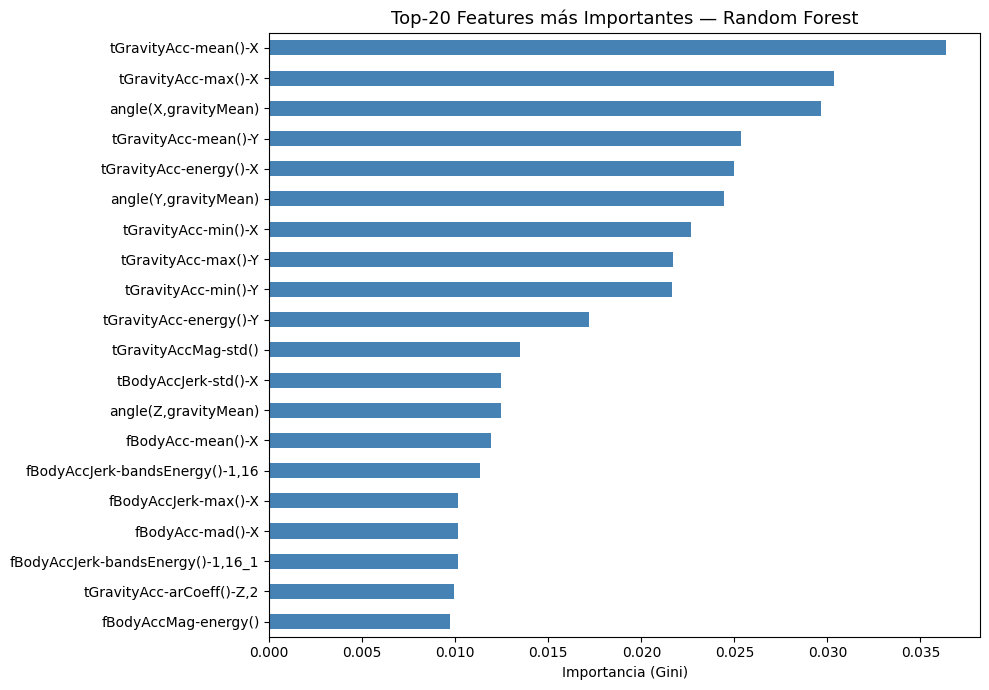

In [14]:
# B2: Graficar top-20 features más importantes
top20 = feature_importances.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top-20 Features más Importantes — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis de importancia de features:**


La feature que más predomina es la media de aceleración de gravedad en el tiempo, por su lado las features basadas en frecuencia están relegadas a puestos menores por lo que se podría concluir que el modelo se basa más en la magnitud promedio de la aceleración que en su variación temporal.

Por su lado el acelerometro predomina sobre el giroscopio en la mayoría de los casos, pues se utiliza este para ver la magnitud de la aceleración en diferentes ejes, permitiendonos identificar los patrones de movimiento de cada actividades.

El sentido físico de que estas features sean las más relevantes es que el acelerometro permite capturar el como se mueve un objeto en el espacio, lo que es fundamental para distinguir entre las actividades presentes en el dataset. Por su lado el giroscopio permite capturar la rotación del objeto, lo que puede ser util para ciertos casos, pero su información es menos relevante para distinguir las activdades, porque no captura la magnitud del movimiento, solo la dirección.

### B.2 Valores SHAP

In [17]:
# TODO B3: Instalar e importar SHAP
# !pip install shap --quiet
import shap
shap.initjs()
print('SHAP importado correctamente.')

SHAP importado correctamente.


In [18]:
# TODO B4: Crear explicador SHAP para el mejor modelo
# Para Random Forest usa TreeExplainer (rápido)
# Para otros modelos usa KernelExplainer con una muestra pequeña (200 obs)

# Opción A — Random Forest (recomendado por velocidad):
explainer = shap.TreeExplainer(rf_model)

# Opción B — Modelo genérico (descomentar si el mejor modelo no es tree-based):
# muestra = shap.sample(X_test, 200, random_state=RANDOM_STATE)
# explainer = shap.KernelExplainer(mejor['modelo_obj'].predict_proba, muestra)

print('Explicador SHAP creado.')

Explicador SHAP creado.


In [19]:
# TODO B5: Calcular valores SHAP (usar muestra de 200 obs para velocidad)
muestra_test = X_test.sample(200, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(muestra_test)
print(f'Forma de shap_values: {np.array(shap_values).shape}')

Forma de shap_values: (200, 561, 6)


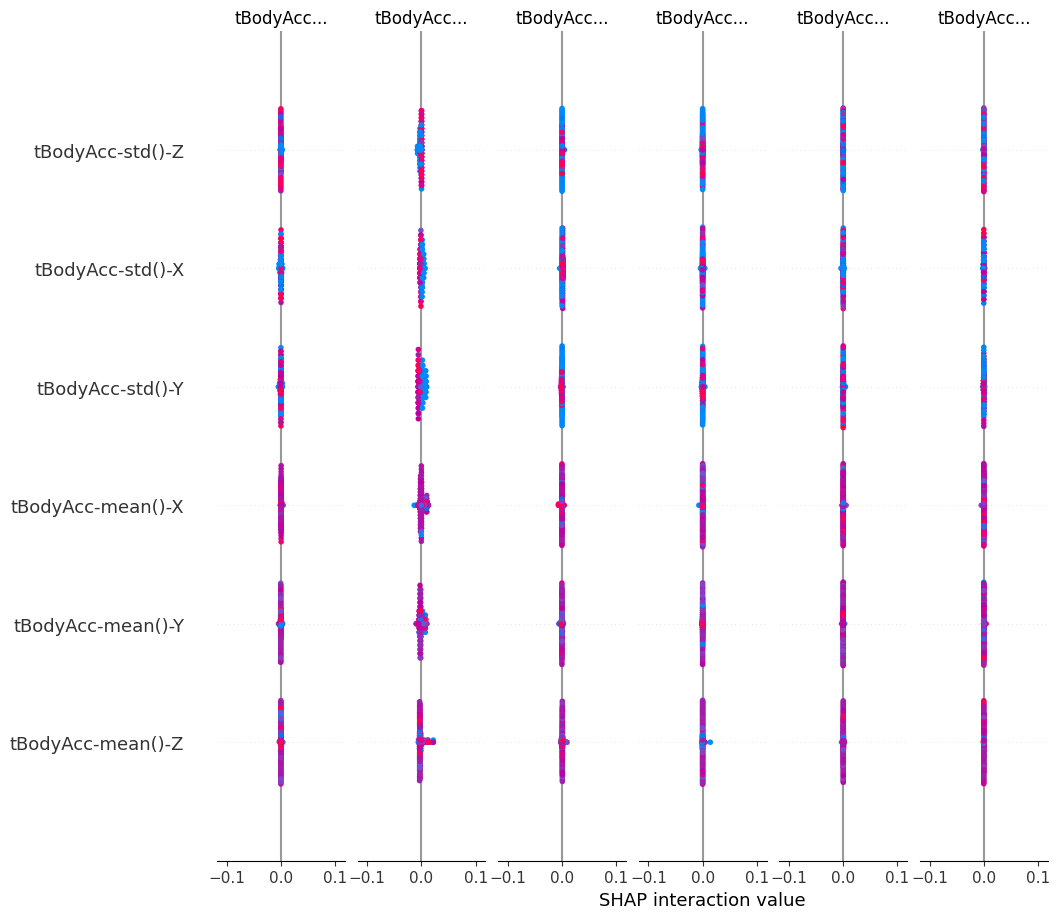

In [28]:
# TODO B6: SHAP Summary Plot — features más influyentes globalmente
shap.summary_plot(
    shap_values,
    muestra_test,
    class_names=list(ACTIVITY_LABELS.values()),
    max_display=10
)

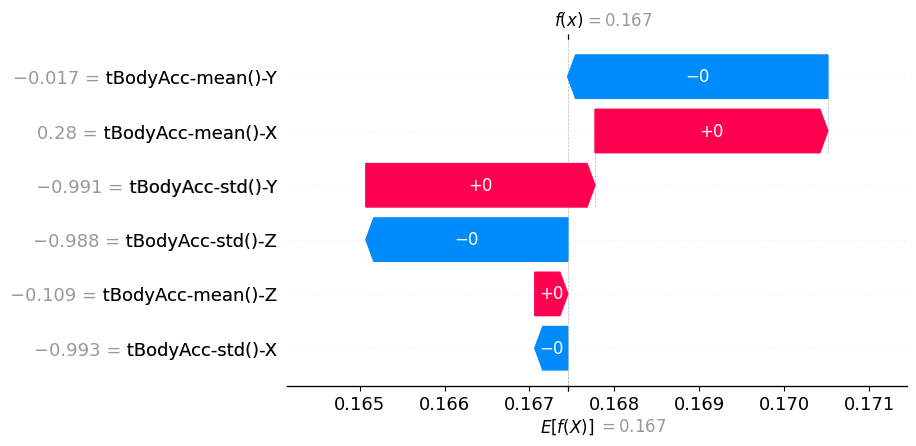

In [50]:
# TODO B7: SHAP Waterfall Plot — análisis de un caso específico
# Elegir una muestra del test set y explicar la decisión del modelo
idx_muestra = 42  # TODO: cambiar por un índice interesante

# Para modelos multiclase, elegir la clase de interés (ej. clase 0)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0][idx_muestra],
        base_values=explainer.expected_value[0],
        data=muestra_test.iloc[idx_muestra],
        feature_names=feature_names
    )
)

**Análisis de interpretabilidad:**

1. **¿Las features más importantes tienen sentido físico para HAR?**

Las features importantes miden la aceleración gravitacional y la orientación del dispositivo en el espacio, el sentido físico que posee es que permite distinguir entre actividades estáticas y dinámicas facilmente basandonos en la aceleración, por lo que tienen mucho sentido.

2. **¿El modelo usa features de tiempo, frecuencia, o ambas?**

El modelo utiliza principalmente features basadas en el tiempo, especialmente aquellas relacionadas con la aceleración gravitacional, las features de frecuencia poseen menor efecto en el modelo por lo que son ignoradas.

3. **¿Encontraron algún hallazgo sorprendente o contra-intuitivo?**

El hecho de que las features relacionadas con la aceleración gravitacional sean las más importantes es intuitivo, específicamente sorprende que las features simples (como la media y máximo de aceleración en el eje X) sean más relevantes que las features de frecuencia más complejas.

4. **Si tuvieran que explicar este modelo a un médico o kinesiólogo, ¿cómo lo harían?**

El modelo analiza el movimiento de un telefono en el espacio, midiendo desde la cintura de un paciente para identificar qué actividad está realizando. El modelo permite identificar las actividades típicas de caminar, subir escaleras, bajar escaleras, sentarse, pararse y acostarse lo que puede permitir al area de la kionesiología tener resumenes de las actividades realizadas por el paciente o incluso detectar caidas o movimientos anormales.